# Mixture of Mixture of Gaussians Example

In [43]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import matplotlib
import scipy
from copy import copy
from sklearn.preprocessing import KernelCenterer

#import code to generate data and do clustNP
from sample_distributions import pair_sample_mixture_of_GMs
from NDIGO import gauss_kernal_mat, proj_simplex

# Set Parameters

In [44]:
np.random.seed(123)

n = 150 # number of total paired samples
nhold = 100
ntest = 100
M = 2   # true number of mixture components for our KDE
Mprime = 1
d = 1   # ambient dimension 

#w_outer = np.random.rand(M,) # true KDE mixture proportions
w_outer = np.ones((M,))
w_outer *= 1/np.sum(w_outer)
w_inner = np.ones((M,1))
#mus = 2*np.random.randn(1, d, M) # true means for each mixture distribution
mus = np.ones((1, d, M))
#mus[0,0,0] = -2
sigmas = np.ones((1,d,d,M))


noise_sd = 0.8

# Generate Data

In [45]:
X, component_ids, pair_ids = pair_sample_mixture_of_GMs(mus, sigmas, w_outer, w_inner, n=n)
Xh, cid_h, pid_h = pair_sample_mixture_of_GMs(mus, sigmas, w_outer, w_inner, n=nhold)
Xte, cid_te, pid_te = pair_sample_mixture_of_GMs(mus, sigmas, w_outer, w_inner, n=ntest)
w_outer

X = np.random.uniform(-2,2,(2*n,1)) #just reuse component ids since all are coming from the same distribution

### Plot Pairs as endpoints of line segments

Text(0.5, 0, 'x')

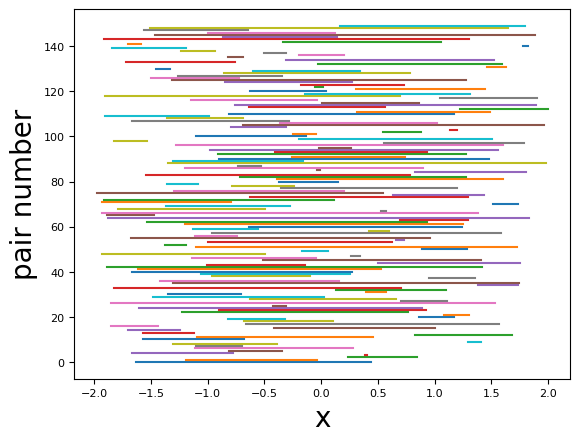

In [46]:
for i in range(n):
    pair = X[pair_ids==i]
    plt.plot(pair, [i,i])
plt.ylabel("pair number")
plt.xlabel("x")

# Generate func vals

# Linear

In [47]:
Y = np.ndarray((2*n,1))
Y[(component_ids==0)] = 5*X[component_ids==0] -4
Y[(component_ids==1)] = -2*X[component_ids==1] + 5
Ytrue = copy(Y)
Y = Y + np.random.normal(0, noise_sd, Y.shape)

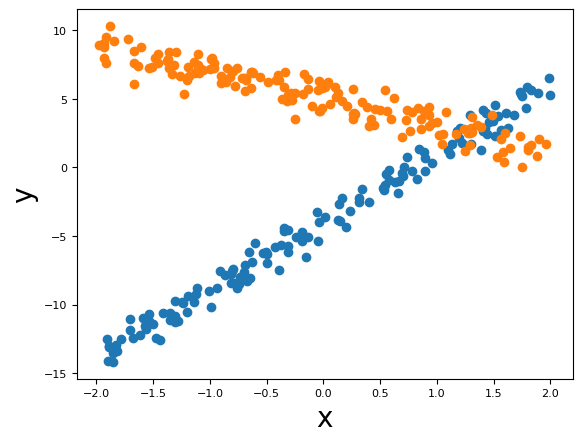

In [48]:
plt.scatter(X[component_ids==0],Y[component_ids==0])
plt.scatter(X[component_ids==1],Y[component_ids==1])
idx = np.argsort(X.flatten())
X_sorted = X.flatten()[idx]
Y_sorted = Y.flatten()[idx]
plt.xlabel("x")
plt.ylabel("y")
plt.rc('axes', labelsize=20)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=8)    # fontsize of the tick labels
plt.rc('ytick', labelsize=8)    # fontsize of the tick labels
#plt.plot(X_sorted.flatten(), Y_sorted.flatten(), color='r')

Text(0.5, 0, 'x')

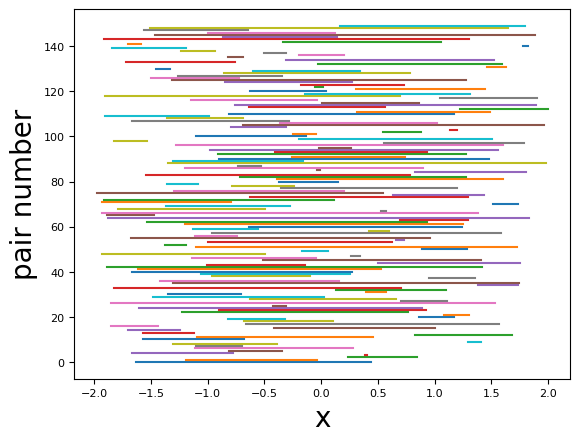

In [49]:
for i in range(n):
    pair = X[pair_ids==i]
    plt.plot(pair, [i,i])
plt.ylabel("pair number")
plt.xlabel("x")

# Nonlinear

In [50]:
Y = np.ndarray((2*n,1))
Y[(component_ids==0)] = X[component_ids==0]**3 - X[component_ids==0]
Y[(component_ids==1)] = -X[component_ids==1]**4 + X[component_ids==1]**2
Ytrue = copy(Y)
Y = Y + np.random.normal(0, noise_sd, Y.shape)

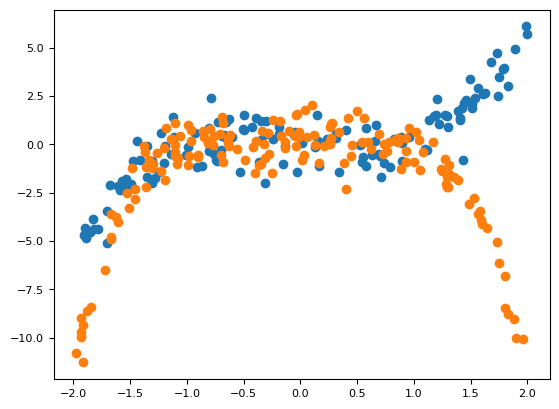

In [51]:
plt.scatter(X[component_ids==0],Y[component_ids==0])
plt.scatter(X[component_ids==1],Y[component_ids==1])
idx = np.argsort(X.flatten())
X_sorted = X.flatten()[idx]
Y_sorted = Y.flatten()[idx]
#plt.plot(X_sorted.flatten(), Y_sorted.flatten(), color='r')

# EM

In [52]:
def lstsq_nesterov(X, Y, alpha0, maxiter=2000):
    Y = Y.flatten()
    ss = 1/np.linalg.norm(X, ord='fro')**2
    alpha = alpha0
    z = alpha0
    gamma = 1
    XtX = X.T@X
    XtY = X.T@Y
    for i in range(maxiter):
        alpha_old = alpha
        alpha = z + ss*(XtY-XtX@z)
        gamma = (np.sqrt(4*gamma**2 + gamma**4) - gamma**2)*0.5
        beta = gamma*(1-1/gamma)
        z = alpha + beta*(alpha - alpha_old)
    return alpha  

In [53]:
# # define model
# model = MyNN()

# for em_iter in range(T):

#     # E-step
#     gamma = compute_responsibilities(...)

#     # M-step (train NN with weights gamma)
#     for step in range(k):
#         preds = model(x)
#         loss = weighted_loss(preds, y, gamma)
#         loss.backward()
#         optimizer.step()


In [54]:
import torch
import torch.nn as nn
import torch.optim as optim

# -------------------------
# Simple feedforward network
# -------------------------
class Net(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)


# -------------------------
# Weighted loss
# -------------------------
def weighted_mse(pred, target, weights):
    # pred: (n, d)
    # target: (n, d)
    # weights: (n,)
    loss = (pred - target)**2
    loss = loss.mean(dim=1)        # per-sample loss (n,)
    return (weights * loss).sum() / weights.sum()


# -------------------------
# E-step (example placeholder)
# -------------------------
# def compute_responsibilities(X, Y, w, models):
#     X = torch.tensor(X, dtype=torch.float32)
#     Y = torch.tensor(Y, dtype=torch.float32)
#     # returns gamma: (n, M)
#     # You’ll replace this with your actual model likelihoods
#     n = X.shape[0]
#     M = len(models)
#     gamma = np.zeros((n,M))
#     # gamma = torch.ones(n, M) / M
#     for im in range(M):
#         mu = models[im](X)
        
#         Delta = (Y - mu)**2 #square loss for each observation for each component
#         #Delta = np.exp((1/(2*noise_sd**2))*(Delta[0::2] + Delta[1::2]))*w #add pairs and scale by mixing weights
#         Delta = (np.exp((1/(2*noise_sd**2))) + np.exp((Delta[0::2] + Delta[1::2])))*w
#         R =  ( Delta.T * (1/np.sum(Delta, axis=1)) ).T
#         gamma[:,im] = R

#     return torch.tensor(gamma, dtype=torch.float32)

def compute_responsibilities(x, Y, w, models, noise_sd):
    x = torch.tensor(x, dtype=torch.float32)
    Y = torch.tensor(Y, dtype=torch.float32)
    
    n = x.shape[0]
    M = len(models)
    
    gamma = torch.zeros((int(n), int(M)), dtype=torch.float32)
    
    w_tensor = torch.tensor(w, dtype=torch.float32)
    log_probs = []

    for im in range(M):
        mu = models[im](x)
        
        Delta = (Y - mu)**2
        log_likelihood = -Delta / (2 * noise_sd**2)
        
        log_prior = torch.log(w_tensor[im])
        
        log_probs.append(log_likelihood.squeeze() + log_prior)

    log_probs = torch.stack(log_probs, dim=1)

    gamma = torch.softmax(log_probs, dim=1)
    
    # for im in range(M):
    #     mu = models[im](x)               # shape (n, d)

    #     print("Mu", mu[-1:-10])
    #     # Delta = (Y - mu)**2               # per-sample squared error
        
    #     # # example of pairing and weighting in PyTorch
    #     # Delta_pairs = Delta[0::2] + Delta[1::2]        # adjust if d != 2
    #     # Delta_exp = torch.exp(Delta_pairs)
        
    #     # const_term = torch.exp(torch.tensor(1/(2*noise_sd**2), dtype=torch.float32))
    #     # Delta_weighted = (const_term + Delta_exp) * w_tensor
        
    #     # # normalize to sum to 1 per row (soft assignment)
    #     # R = Delta_weighted / torch.sum(Delta_weighted)
    #     # gamma[:, im] = R
    #     Delta = (Y - mu)**2             # shape (n,1)
    #     print("y-mu", Delta[0,:])
    #     Delta_weighted = (torch.exp(torch.tensor(1/(2*noise_sd**2), dtype=torch.float32)) + torch.exp(Delta)) * w_tensor
    #     print("delta_weighted", Delta_weighted[0,:])
    #     gamma[:, im] = (Delta_weighted / Delta_weighted.sum(dim=0))[:,0]
    #     print("gamma:", gamma[0,:])

    return gamma


kern_width = 0.8

K = gauss_kernal_mat(X,X,sigma=kern_width)
# transformer = KernelCentere
#r().fit(K)
# K = transformer.transform(K)
w, A = scipy.sparse.linalg.eigs(K, k=M)
w = np.real(w)
A = np.real(A)
w = w/np.sum(w)
maxiter = 30

R = np.zeros((n,M))


# -------------------------
# Main EM loop
# -------------------------

def EM_train(x, y, M, em_iters=10, inner_steps=10):
    n, d = x.shape
    x = torch.tensor(x, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32)

    # initialize models + optimizers
    models = [Net(d, 32, y.shape[1]) for _ in range(M)]
    opts = [optim.Adam(m.parameters(), lr=1e-3) for m in models]

    for em_iter in range(em_iters):

        # -----------------
        # E-step
        # -----------------
        gamma = compute_responsibilities(x, y, w, models, noise_sd)  # (n, M)
    

        # Delta = (Y - K@A)**2 #square loss for each observation for each component
        # #Delta = np.exp((1/(2*noise_sd**2))*(Delta[0::2] + Delta[1::2]))*w #add pairs and scale by mixing weights
        # Delta = (np.exp((1/(2*noise_sd**2))) + np.exp((Delta[0::2] + Delta[1::2])))*w
        # R =  ( Delta.T * (1/np.sum(Delta, axis=1)) ).T
        
        # log_probs = []

        # for im in range(M):
        #     mu = models[im](x)
        #     log_p = -(y - mu)**2 / (2 * noise_sd)
        #     log_probs.append(log_p)

        # log_probs = torch.stack(log_probs, dim=1)  # (n, M)

        # gamma = torch.softmax(log_probs, dim=1)
    
        # -----------------
        # M-step
        # -----------------
        for m in range(M):
            model = models[m]
            opt = opts[m]

            weights = gamma[:, m].detach()  # (n,)

            for _ in range(inner_steps):
                opt.zero_grad()

                pred = model(x)
                loss = weighted_mse(pred, y, weights)

                loss.backward()
                opt.step()

        # print(f"EM iter {em_iter} done")

    return models

In [55]:
X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)

models = EM_train(X_tensor, Y_tensor, M=2, em_iters=100, inner_steps=100)

C:\Users\jj\AppData\Local\Temp\ipykernel_8032\1843046537.py:129: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32)
C:\Users\jj\AppData\Local\Temp\ipykernel_8032\1843046537.py:130: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(y, dtype=torch.float32)
C:\Users\jj\AppData\Local\Temp\ipykernel_8032\1843046537.py:57: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32)
C:\Users\jj\AppData\Local\Temp\ipykernel_8032\1843046537.py:58: UserWarning: To copy cons

In [56]:
# kern_width = 0.8

# K = gauss_kernal_mat(X,X,sigma=kern_width)
# # transformer = KernelCentere
# #r().fit(K)
# # K = transformer.transform(K)
# w, A = scipy.sparse.linalg.eigs(K, k=M)
# w = np.real(w)
# A = np.real(A)
# w = w/np.sum(w)
# maxiter = 30

# R = np.zeros((n,M))

# for i in range(maxiter):
#     print(i)
#     # E-step
#     Delta = (Y - K@A)**2 #square loss for each observation for each component
#     #Delta = np.exp((1/(2*noise_sd**2))*(Delta[0::2] + Delta[1::2]))*w #add pairs and scale by mixing weights
#     Delta = (np.exp((1/(2*noise_sd**2))) + np.exp((Delta[0::2] + Delta[1::2])))*w
#     R =  ( Delta.T * (1/np.sum(Delta, axis=1)) ).T
    
#     # M-step
#     w = np.sum(R,axis=0) / n
#     for j in range(M):
#         Rm = np.repeat(R[:,j]**0.5,2,axis=0)
#         A[:,j] = lstsq_nesterov((K.T*Rm).T, (Y.T*Rm).T, A[:,j])
#         #A[:,j] = np.linalg.lstsq((K.T*Rm).T, (Y.T*Rm).T, rcond=None)[0].flatten()
#         print("final: ", np.linalg.norm((Y.T*Rm).T.flatten() - (K.T*Rm).T@A[:,j]))


In [57]:
print(R)

[[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 

In [58]:
Rprime = copy(R)
Rprime[R<0.01] = 0
Rprime[R>0.99] = 1
print(Rprime)

[[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 

# Check out the results

In [59]:
# Y_hat = np.zeros((2*n,M))
# for j in range(M):
#         #Rm = np.repeat(R[:,j]**0.5,2,axis=0)
#         #Y_hat[:,j] = (K.T*Rm).T@A[:,j]
#         Y_hat[:,j] = K@A[:,j]

[-1.09016380e+01 -1.08193245e+01 -1.07370119e+01 -1.06546984e+01
 -1.05723877e+01 -1.04900742e+01 -1.04077606e+01 -1.03254471e+01
 -1.02431355e+01 -1.01608219e+01 -1.00785093e+01 -9.99619770e+00
 -9.91388512e+00 -9.83157158e+00 -9.74925804e+00 -9.66694736e+00
 -9.58463383e+00 -9.50231934e+00 -9.42000675e+00 -9.33769608e+00
 -9.25538254e+00 -9.17306900e+00 -9.09075737e+00 -9.00844479e+00
 -8.92613029e+00 -8.84381676e+00 -8.76150703e+00 -8.67919350e+00
 -8.59687996e+00 -8.51456642e+00 -8.43225479e+00 -8.34994125e+00
 -8.26762772e+00 -8.18531799e+00 -8.10300350e+00 -8.02068996e+00
 -7.93837786e+00 -7.85606623e+00 -7.77375221e+00 -7.69143963e+00
 -7.60912561e+00 -7.52681494e+00 -7.44450235e+00 -7.36218834e+00
 -7.27987671e+00 -7.19756365e+00 -7.11525011e+00 -7.03293657e+00
 -6.95062637e+00 -6.86831236e+00 -6.78599834e+00 -6.70368528e+00
 -6.62137461e+00 -6.53906059e+00 -6.45674801e+00 -6.37443733e+00
 -6.29212332e+00 -6.20981026e+00 -6.12749624e+00 -6.04518557e+00
 -5.96287203e+00 -5.88055

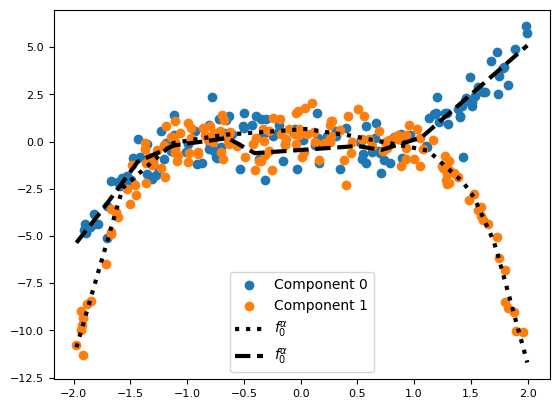

In [60]:
plt.scatter(X[component_ids==0],Y[component_ids==0], label="Component 0")
plt.scatter(X[component_ids==1],Y[component_ids==1], label="Component 1")

xx = np.reshape(np.linspace(np.min(X),np.max(X),1000), (1000,1))
xx_tensor = torch.tensor(xx, dtype=torch.float32)
# Ktest = gauss_kernal_mat(xx,X,sigma=kern_width)
# Yhat = Ktest@A
Yhat_tens = torch.zeros((xx_tensor.shape[0], M), dtype=torch.float32)  # tensor instead of np.zeros

for m in range(M):
    # forward pass
    Yhat_tens[:, m] = models[m](xx_tensor).squeeze()

Yhat = Yhat_tens.detach().numpy()

print(Yhat[:,0])
print(Yhat[:,1])
plt.plot(xx, Yhat[:,0], 'k:', linewidth=3, label=r"$f_0^\alpha$")
plt.plot(xx, Yhat[:,1], 'k--', linewidth=3, label=r"$f_0^\alpha$")

Rdouble = np.repeat(R,2,axis=0)
correct_assignments = max(sum(component_ids==np.argmax(Rdouble,axis=1) ), 
                          sum((1-component_ids)==np.argmax(Rdouble,axis=1)) 
                         ) / (2*n)
print(f"Prop Correct Mixture Assignment = {correct_assignments}")

plt.rcParams.update({'font.size': 10})
plt.legend()

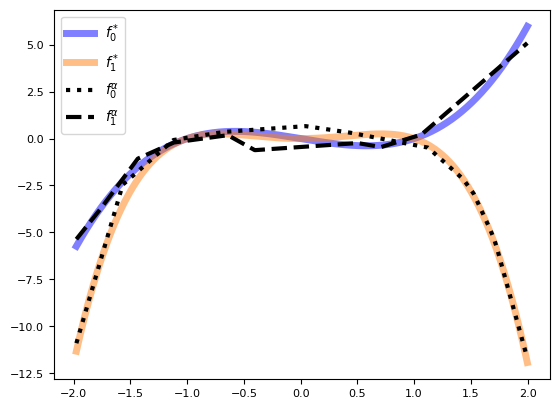

In [64]:
plt.plot(xx, xx**3-xx, 'b', linewidth=5, label="$f_0^*$", alpha=0.5)
plt.plot(xx, -xx**4+xx**2, 'tab:orange', linewidth=5, label="$f_1^*$", alpha=0.5)
plt.plot(xx, Yhat[:,0], 'k:', linewidth=3, label=r"$f_0^\alpha$")
plt.plot(xx, Yhat[:,1], 'k--', linewidth=3, label=r"$f_1^\alpha$")
plt.rcParams.update({'font.size': 10})
plt.legend()


In [63]:
Rdouble = np.repeat(R,2,axis=0)
plt.scatter(X[np.argmax(Rdouble,axis=1)==0],Yhat[np.argmax(Rdouble,axis=1)==0,0])
plt.scatter(X[np.argmax(Rdouble,axis=1)==1],Yhat[np.argmax(Rdouble,axis=1)==1,1])
idx = np.argsort(X.flatten())
X_sorted = X.flatten()[idx]
Y_sorted = Y.flatten()[idx]
#plt.plot(X_sorted.flatten(), Y_sorted.flatten(), color='r')

IndexError: boolean index did not match indexed array along axis 0; size of axis is 1000 but size of corresponding boolean axis is 300

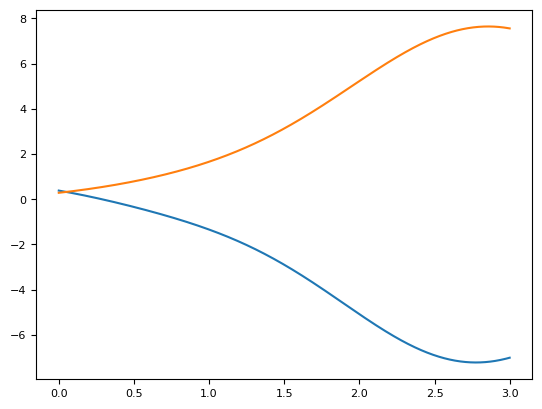

In [ ]:
xx = np.reshape(np.linspace(0,3,1000), (1000,1))
Ktest = gauss_kernal_mat(xx,X,sigma=0.95)
Yhat = Ktest@A
plt.plot(xx, Yhat[:,0])
plt.plot(xx, Yhat[:,1])